In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Getting the data from sql into a pandas dataframe to work with easily.

In [2]:
import os

# Resolve the database path relative to this notebook's location
# so it works regardless of where Jupyter was launched from
notebook_dir = os.path.dirname(os.path.abspath('pre-process.ipynb'))
db_path = os.path.join(notebook_dir, 'database.sqlite')

# Fallback: if running from project root
if not os.path.exists(db_path):
    db_path = os.path.join('pre-processing', 'database.sqlite')

print("Using database:", db_path)
conn = sqlite3.connect(db_path)

query = """
    SELECT 
        m.id, 
        m.date,
        ht.team_long_name AS home_team,
        at.team_long_name AS away_team,
        m.home_team_goal, 
        m.away_team_goal,
        m.home_team_api_id,
        m.away_team_api_id
    FROM Match m
    LEFT JOIN Team ht ON m.home_team_api_id = ht.team_api_id
    LEFT JOIN Team at ON m.away_team_api_id = at.team_api_id
"""
matches = pd.read_sql_query(query, conn)
matches.head()

Using database: C:\Users\Admin\Desktop\ML Homeworks\CSC4850_GroupPoject\pre-processing\database.sqlite


,id,date,home_team,away_team,home_team_goal,away_team_goal,home_team_api_id,away_team_api_id
0,1,2008-08-17 00:00:00,KRC Genk,Beerschot AC,1,1,9987,9993
1,2,2008-08-16 00:00:00,SV Zulte-Waregem,Sporting Lokeren,0,0,10000,9994
2,3,2008-08-16 00:00:00,KSV Cercle Brugge,RSC Anderlecht,0,3,9984,8635
3,4,2008-08-17 00:00:00,KAA Gent,RAEC Mons,5,0,9991,9998
4,5,2008-08-16 00:00:00,FCV Dender EH,Standard de Liège,1,3,7947,9985


### 1. Create Target Variable (Outcome)
We need a single target variable for our ML models. Let's create `match_outcome` from the perspective of the Home Team: `0` = Draw, `1` = Win, `2` = Loss.

In [3]:
def get_outcome(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 1 # Win
    elif row['home_team_goal'] < row['away_team_goal']:
        return 2 # Loss
    else:
        return 0 # Draw

matches['match_outcome'] = matches.apply(get_outcome, axis=1)
matches['match_outcome'].value_counts()

match_outcome
1    11917
2     7466
0     6596
Name: count, dtype: int64

### 2. Aggregate and Join Team Attributes
We need numerical team stats to run through PCA. We will take the average stats for each team.

In [4]:
# Query team attributes
team_query = "SELECT * FROM Team_Attributes"
team_attributes = pd.read_sql_query(team_query, conn)

# Keep only numeric columns and average them for each team
numeric_team_cols = team_attributes.select_dtypes(include=[np.number]).columns
team_stats_avg = team_attributes[numeric_team_cols].groupby('team_api_id').mean().reset_index()

# Drop useless ID columns from the average stats
team_stats_avg = team_stats_avg.drop(columns=['id', 'team_fifa_api_id'], errors='ignore')

# Merge home team attributes
matches = pd.merge(matches, team_stats_avg.add_prefix('home_'), 
                   left_on=['home_team_api_id'], right_on=['home_team_api_id'], how='left')

# Merge away team attributes
matches = pd.merge(matches, team_stats_avg.add_prefix('away_'), 
                   left_on=['away_team_api_id'], right_on=['away_team_api_id'], how='left')
matches.head()

,id,date,home_team,away_team,home_team_goal,away_team_goal,home_team_api_id,away_team_api_id,match_outcome,home_buildUpPlaySpeed,...,home_defenceTeamWidth,away_buildUpPlaySpeed,away_buildUpPlayDribbling,away_buildUpPlayPassing,away_chanceCreationPassing,away_chanceCreationCrossing,away_chanceCreationShooting,away_defencePressure,away_defenceAggression,away_defenceTeamWidth
0,1,2008-08-17 00:00:00,KRC Genk,Beerschot AC,1,1,9987,9993,0,56.333333,...,59.833333,46.000000,NaN,41.500000,46.000000,53.500000,53.750000,48.250000,49.000000,58.750000
1,2,2008-08-16 00:00:00,SV Zulte-Waregem,Sporting Lokeren,0,0,10000,9994,0,55.500000,...,47.833333,64.000000,45.0,53.500000,44.000000,47.666667,54.333333,48.833333,55.166667,55.500000
2,3,2008-08-16 00:00:00,KSV Cercle Brugge,RSC Anderlecht,0,3,9984,8635,2,53.666667,...,64.666667,51.333333,46.0,45.166667,63.500000,55.000000,51.333333,59.666667,47.666667,63.833333
3,4,2008-08-17 00:00:00,KAA Gent,RAEC Mons,5,0,9991,9998,1,54.166667,...,45.666667,51.666667,50.0,51.666667,55.000000,60.666667,46.000000,46.000000,45.000000,47.000000
4,5,2008-08-16 00:00:00,FCV Dender EH,Standard de Liège,1,3,7947,9985,2,NaN,...,NaN,59.666667,45.0,60.333333,54.666667,58.833333,61.333333,51.500000,57.500000,56.500000


### 3. Handle Missing Values and Drop Identifiers
PCA and SVM will crash if they encounter missing values or try to process non-numeric IDs.

In [5]:
# Data Symmetrization: Duplicate matches for both home and away perspectives
df1 = matches.copy()
df1['is_home'] = 1

df2 = matches.copy()
df2['is_home'] = 0
df2['match_outcome'] = df2['match_outcome'].map({1: 2, 2: 1, 0: 0})

home_cols = [c for c in matches.columns if c.startswith('home_')]
away_cols = [c for c in matches.columns if c.startswith('away_')]
rename_df1 = {c: c.replace('home_', 'team_') for c in home_cols}
rename_df1.update({c: c.replace('away_', 'opponent_') for c in away_cols})
rename_df2 = {c: c.replace('away_', 'team_') for c in away_cols}
rename_df2.update({c: c.replace('home_', 'opponent_') for c in home_cols})

df1 = df1.rename(columns=rename_df1)
df2 = df2.rename(columns=rename_df2)
matches = pd.concat([df1, df2], ignore_index=True)

# Keep only numerical columns for modeling
# First, sort by date for temporal train/test split later
matches = matches.sort_values(by='date').reset_index(drop=True)

numeric_cols = matches.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = matches[numeric_cols].copy()

# Drop identifiers and goals (since we don't know goals before a match starts!)
cols_to_drop = ['id', 'team_team_goal', 'opponent_team_goal', 'team_team_api_id', 'opponent_team_api_id']
cols_to_drop.extend([col for col in df_numeric.columns if 'id' in col]) # drop other nested IDs
df_numeric = df_numeric.drop(columns=[c for c in cols_to_drop if c in df_numeric.columns], errors='ignore')

# Impute missing values with the median of the column
df_clean = df_numeric.fillna(df_numeric.median())
print("Remaining missing values:", df_clean.isna().sum().sum())

Remaining missing values: 0


### 4. Standardize Features
Distance-based models (KNN, SVM, PCA) require all features to be standardized (mean=0, std=1).

In [6]:
# Separate features (X) and target (y)
X = df_numeric.drop('match_outcome', axis=1)
y = df_numeric['match_outcome']

# --- TEMPORAL TRAIN/TEST SPLIT (done BEFORE imputation to prevent data leakage) ---
# shuffle=False preserves chronological order: train on past, test on future matches.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- IMPUTE MISSING VALUES USING TRAINING MEDIAN ONLY ---
# Computing the median from X_train only ensures the test set has zero influence
# on the imputed values, keeping the pipeline leak-free.
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test  = X_test.fillna(train_median)

print("Missing values in X_train after imputation:", X_train.isna().sum().sum())
print("Missing values in X_test  after imputation:", X_test.isna().sum().sum())

# --- STANDARDIZE (fit on train only, transform both) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nShape of scaled training features:", X_train_scaled.shape)
print("Shape of scaled testing features: ", X_test_scaled.shape)

Missing values in X_train after imputation: 0
Missing values in X_test  after imputation: 0

Shape of scaled training features: (41566, 17)
Shape of scaled testing features:  (10392, 17)


Original number of features: 17
Reduced number of features (Principal Components): 15


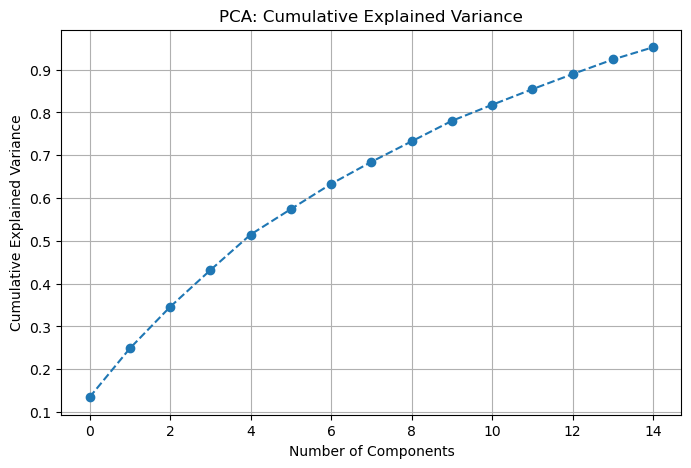

In [7]:
# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95)
# Fit on training set ONLY, transform both
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Reduced number of features (Principal Components):", X_train_pca.shape[1])

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [8]:
import numpy as np
import pandas as pd

pc_cols = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

# Use numpy.savetxt to avoid pandas string-conversion MemoryError
np.savetxt('X_train_pca.csv', X_train_pca, delimiter=',', header=','.join(pc_cols), comments='')
np.savetxt('X_test_pca.csv',  X_test_pca,  delimiter=',', header=','.join(pc_cols), comments='')

# Save targets
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

print("Data successfully saved to CSVs in the pre-processing folder!")

Data successfully saved to CSVs in the pre-processing folder!
